# Partial or full automation

**Reader question.** How does uncertainty over the future production regime change
what public installed-capital equity can insure?

**Answer in brief.** With one possible automation mark and one nonzero event payoff,
the financial event risk is one-dimensional and can be spanned. With two possible
successors—partial automation and labour-free AK—and one installed-equity payoff, the
attainable event-payoff set is generically only a line. The fiscal valuation residual
orthogonal to that line remains uninsurable by changing the quantity of the same claim.

That rank result is analytical. Existing marked-Poisson numbers are shown only as a
**quarantine-affected diagnostic** explaining why this notebook reports no policy or
welfare magnitude.

## Model branches and timing

The common small-open closure fixes world safe rates and distinguishes physical event
intensities from risk-neutral intensities. Workers cannot trade the securities. The
government can use safe debt and installed-capital equity; foreigners absorb residual
positions. The event is totally inaccessible, physical capital is continuous, and the
predictable pre-event portfolio pays before successor rebalancing. A flow tax has no
event atom.

The inherited augmented state $(S_0,M_0)$ includes physical and financial states plus
any promises, multipliers, or institutional commitments. It must be held fixed within
a valid comparison.

| Branch | Successor support | Traded event payoff | Financial rank |
|---|---:|---|---:|
| Single-AK | one mark | nonzero scalar total gain | one |
| AK-or-partial | two marks $(P,F)$ | vector $(J_P,J_F)$ from one claim | generically one |

The two branches change technology and event support, so they are not themselves a
causal welfare comparison.

## The one-payoff line in a two-mark space

The next cell uses arbitrary vectors to show the exact projection logic. The fiscal-
valuation residual $u=(u_P,u_F)$ is decomposed into a component along the installed-
equity payoff $J=(J_P,J_F)$ and an orthogonal component. At an interior optimum, the
portfolio FOC restricts the projection onto $J$; it does not impose one equality for
each mark.

| Illustrative geometry check | Value |
|---|---:|
| rank of one installed-equity payoff | 1 |
| $u_\perp'J$ | -2.78e-17 |
| unspanned share of $\lVert u\rVert$ | 99.5% |

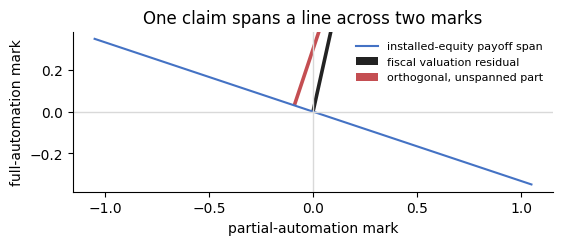

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

payoff = np.array([0.75, -0.25])
fiscal_residual = np.array([0.20, 0.90])
parallel = (fiscal_residual @ payoff) / (payoff @ payoff) * payoff
orthogonal = fiscal_residual - parallel

display(
    Markdown(
        "| Illustrative geometry check | Value |\n|---|---:|\n"
        f"| rank of one installed-equity payoff | {np.linalg.matrix_rank(payoff.reshape(2, 1))} |\n"
        f"| $u_\\perp'J$ | {orthogonal @ payoff:.2e} |\n"
        f"| unspanned share of $\\lVert u\\rVert$ | {np.linalg.norm(orthogonal)/np.linalg.norm(fiscal_residual):.1%} |"
    )
)

fig, ax = plt.subplots(figsize=(6.2, 5.0))
scale = np.linspace(-1.4, 1.4, 80)
ax.plot(scale * payoff[0], scale * payoff[1], color="#4472C4", label="installed-equity payoff span")
ax.quiver(0, 0, *fiscal_residual, angles="xy", scale_units="xy", scale=1,
          color="#222222", label="fiscal valuation residual")
ax.quiver(*parallel, *orthogonal, angles="xy", scale_units="xy", scale=1,
          color="#C44E52", label="orthogonal, unspanned part")
ax.axhline(0, color="0.85", linewidth=1)
ax.axvline(0, color="0.85", linewidth=1)
ax.set_xlabel("partial-automation mark")
ax.set_ylabel("full-automation mark")
ax.set_title("One claim spans a line across two marks")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## The stationary successor algebra that is implemented

The full-automation precursor implements stationary endpoint calculations such as

$$
\iota(q)=\frac{q-1}{\varphi},\qquad
g(q)=\frac{\log q}{\varphi}-\delta,
$$

zero-tax root searches, fixed-mark compatibility, incomplete-market fixtures, and
payoff-rank diagnostics. These are useful building blocks. They are not a calibrated
pre-event Ramsey transition. The later deterministic BVP code is explicitly synthetic
numerical scaffolding and is therefore excluded from the policy evidence here.

## Why the current marked-Poisson run is quarantined

The compact export below summarizes only coverage and viability labels from the pinned
CS005 bundle. Candidate counts are not economic estimates. In particular, a candidate
that passes a subset of checks is not a solution from the inherited date-zero state.

**Status:** `exploratory_diagnostic`; `quarantine_affected`  
**Run:** `RUN-20260902T220418Z-CS005-5a264b83-01`  

| Diagnostic count | Value |
|---|---:|
| atlas candidates | 4 |
| pass pre-W5 checks | 1 |
| fully admissible after W5 | 0 |
| match inherited date-zero state | 0 |
| W5: `certified_infeasible_on_declared_domain` | 1 |
| W5: `certified_viable` | 1 |
| W5: `frontier_unresolved` | 2 |

The PM08 backward-tail check meets its declared 1e-08 tolerance: **True**. This certifies only the declared post-mark tail domain.

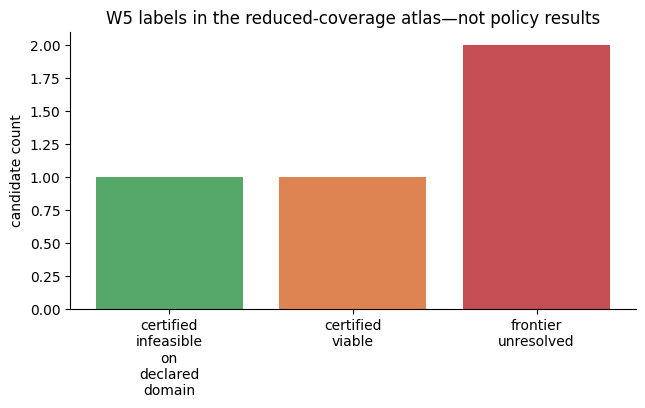

In [2]:
import json
from pathlib import Path

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs005_poisson_status_snapshot.json"),
        Path("data/cs005_poisson_status_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))
atlas = snapshot["candidate_atlas"]
labels = atlas["strict_viability_label_counts"]

lines = [
    f"**Status:** `{snapshot['result_use_status']}`; `{snapshot['disposition']}`  ",
    f"**Run:** `{snapshot['source']['run_id']}`  ",
    "",
    "| Diagnostic count | Value |",
    "|---|---:|",
    f"| atlas candidates | {atlas['candidate_count']} |",
    f"| pass pre-W5 checks | {atlas['pre_w5_admissible_count']} |",
    f"| fully admissible after W5 | {atlas['fully_admissible_count']} |",
    f"| match inherited date-zero state | {atlas['matched_inherited_state_count']} |",
]
for label, count in labels.items():
    lines.append(f"| W5: `{label}` | {count} |")
lines.extend(
    [
        "",
        f"The PM08 backward-tail check meets its declared {snapshot['pm08_tail_tolerance']:.0e} tolerance: "
        f"**{snapshot['pm08_tail_certificate_pass']}**. This certifies only the declared post-mark tail domain.",
    ]
)
display(Markdown("\n".join(lines)))

fig, ax = plt.subplots(figsize=(7.3, 3.6))
clean_labels = [label.replace("_", "\n") for label in labels]
ax.bar(clean_labels, list(labels.values()), color=["#55A868", "#DD8452", "#C44E52"])
ax.set_ylabel("candidate count")
ax.set_title("W5 labels in the reduced-coverage atlas—not policy results")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## What remains before a quantitative notebook

The active marked-Poisson route still needs full root coverage; payoff-rank, tax-span,
and fixed-mark work packages; a closed fiscal-capacity frontier; a date-zero inherited-
state solution; and a bound, fingerprinted specification. The AK-or-partial branch also
needs frozen parameter packets, successor domains, direct tax KKT checks, protection
and announcement-compensation rules, and a canonical transition system.

No current bundle supports a calibrated magnitude, optimal tax or portfolio, global
admissible path, or worker-welfare comparison. Incomplete span can create a tax wedge,
but it neither requires the wedge to be nonzero nor signs it.

## Economic interpretation

The economically important change from one mark to two is not simply “more
uncertainty.” It is a rise in the dimension of successor-state valuation relative to
the dimension of traded event payoffs. The residual orthogonal to $(J_P,J_F)$ survives
any change in the quantity of the single equity claim and can interact with taxes and
investment conditions.

Brownian and Poisson models express the same payoff-space idea in different timing and
technology environments. Their outputs should not be combined as if they were direct
counterfactuals.

## Reproduce and trace

- Marked-Poisson source: [`tai-public-finance-poisson` at `74c736f`](https://github.com/Nathan-Barnard/tai-public-finance-poisson/tree/74c736f8753e65f444eb30443a16adbb62f9c35c)
- Run implementation: `5a264b836ecdfd8e22c868b38680ec8435545fc4`
- Run: `RUN-20260902T220418Z-CS005-5a264b83-01`; objects CP005 and draft CS005
- Full-automation stationary diagnostic source: [`fa/small-open-ak-diagnostic` at `1b1fcd5`](https://github.com/Nathan-Barnard/tai-public-finance-full-automation/tree/1b1fcd5932ac591ed20f80b26734f145903f5642)
- Public export: `notebooks/data/cs005_poisson_status_snapshot.json`
- Environment: upstream `uv.lock`; Python 3.13 with NumPy, SciPy, and PyYAML

The marked-Poisson entrypoint is `uv run python -m tai_public_finance.cs005_marked_poisson.cli --config configs/cs005/P-CS005-REAL-01.json --output-dir outputs/cs005-w5-strict-viability --run-id RUN-20260902T220418Z-CS005-5a264b83-01`. Reproduction does not promote the run beyond its quarantine-affected status.